In [1]:
import os, sys
os.environ["OMP_NUM_THREADS"] = "4"
sys.path.append(os.path.join(os.getcwd(), ".."))
import itertools
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from data.AEML.aeml import get_aeml_new_target_data, select_event
from data.serialize import SerializerSettings
from models.chronos_forecast import get_predictions_chronos
from models.llmtime import get_llmtime_predictions_data
from models.validation_likelihood_tuning import get_autotuned_predictions_data
from models.utils import grid_iter

/home/amir/miniconda3/envs/llmtime/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## AEML event forecasting setup
This notebook loads the new AEML dataset, lets you pick an event window, and compares Chronos against Gemma-7B and Qwen-30B with and without few-shot context.

In [2]:
EVENT_WINDOWS = [
    ("2024-03-01 09:30:00", "2024-03-01 12:00:00"),
    ("2024-03-05 07:00:00", "2024-03-05 11:00:00"),
    ("2024-03-06 09:00:00", "2024-03-06 10:00:00"),
    ("2024-03-07 09:20:00", "2024-03-07 10:30:00"),
    ("2024-03-18 15:00:00", "2024-03-18 17:30:00"),
    ("2024-03-18 21:45:00", "2024-03-18 22:45:00"),
    ("2024-03-02 08:50:00", "2024-03-02 11:30:00"),
    ("2024-03-04 09:00:00", "2024-03-04 11:30:00"),
    ("2024-03-07 17:00:00", "2024-03-07 17:50:00"),
    ("2024-03-10 18:40:00", "2024-03-10 21:10:00"),
    ("2024-03-11 01:10:00", "2024-03-11 02:00:00"),
    ("2024-03-13 08:45:00", "2024-03-13 11:11:00"),
    ("2024-03-12 00:12:00", "2024-03-12 01:00:00"),
    ("2024-03-11 16:00:00", "2024-03-11 18:25:00"),
    ("2024-03-11 22:45:00", "2024-03-11 23:35:00"),
]

event_schedule = pd.DataFrame(EVENT_WINDOWS, columns=["start", "end"]).astype("datetime64[ns]")
event_schedule.index.name = "event_number"
event_schedule

,start,end
event_number,,
0,2024-03-01 09:30:00,2024-03-01 12:00:00
1,2024-03-05 07:00:00,2024-03-05 11:00:00
2,2024-03-06 09:00:00,2024-03-06 10:00:00
3,2024-03-07 09:20:00,2024-03-07 10:30:00
4,2024-03-18 15:00:00,2024-03-18 17:30:00
5,2024-03-18 21:45:00,2024-03-18 22:45:00
6,2024-03-02 08:50:00,2024-03-02 11:30:00
7,2024-03-04 09:00:00,2024-03-04 11:30:00
8,2024-03-07 17:00:00,2024-03-07 17:50:00


In [3]:
EVENT_NUMBER = 2  # choose the event to model
TARGET_COLUMN = "AMP-4"
TRAIN_SIZE = 160
TEST_SIZE = 48
OVERSHOOT_STEPS = 100
OVERSHOOT_MINUTES = None

assert 100 <= TRAIN_SIZE <= 200, "Train size must be between 100 and 200 samples."
assert 30 <= TEST_SIZE <= 80, "Test size must be between 30 and 80 samples."
TRAIN_SIZE, TEST_SIZE

(160, 48)

In [4]:
def prepare_event_series(event_number, train_size, test_size, overshoot_steps=0, overshoot_minutes=None):
    df = get_aeml_new_target_data(Target=TARGET_COLUMN)
    df = df.dropna(subset=[TARGET_COLUMN]).sort_values("Date").reset_index(drop=True)
    overshoot_kwargs = {}
    if overshoot_minutes is not None:
        overshoot_kwargs["overshoot_time"] = pd.Timedelta(minutes=overshoot_minutes)
    elif overshoot_steps:
        overshoot_kwargs["overshoot_steps"] = overshoot_steps
    event_df = select_event(df, event_number=event_number, **overshoot_kwargs)
    event_df = event_df.dropna(subset=[TARGET_COLUMN]).sort_values("Date").reset_index(drop=True)
    required_length = train_size + test_size
    if len(event_df) < required_length:
        raise ValueError(
            f"Event {event_number} has {len(event_df)} samples; need at least {required_length}. "
            "Increase overshoot or adjust the split sizes."
        )
    event_series = event_df.set_index("Date")[TARGET_COLUMN].astype(float)
    train_series = event_series.iloc[:train_size]
    test_series = event_series.iloc[train_size:train_size + test_size]
    return train_series, test_series, event_series


train_series, test_series, event_series = prepare_event_series(
    event_number=EVENT_NUMBER,
    train_size=TRAIN_SIZE,
    test_size=TEST_SIZE,
    overshoot_steps=OVERSHOOT_STEPS,
    overshoot_minutes=OVERSHOOT_MINUTES,
 )

print(f"Train length: {len(train_series)} | Test length: {len(test_series)}")
print(f"Train range: {train_series.index.min()} → {train_series.index.max()}")
print(f"Test range: {test_series.index.min()} → {test_series.index.max()}")
print(f"Event range: {EVENT_WINDOWS[EVENT_NUMBER][0]} → {EVENT_WINDOWS[EVENT_NUMBER][1]}")

Train length: 160 | Test length: 48
Train range: 2024-03-06 05:40:00 → 2024-03-06 10:58:00
Test range: 2024-03-06 11:00:00 → 2024-03-06 12:34:00
Event range: 2024-03-06 09:00:00 → 2024-03-06 10:00:00


In [5]:
quantile_levels = [0.1, 0.5, 0.9]
chronos_quantiles_tensor, chronos_mean_tensor = get_predictions_chronos(
    input_tensor=torch.tensor(train_series.values, dtype=torch.float32),
    prediction_length=len(test_series),
    quantiles=quantile_levels,
 )

chronos_quantiles_np = chronos_quantiles_tensor.squeeze(0).detach().cpu().numpy()
chronos_mean_np = chronos_mean_tensor.squeeze(0).detach().cpu().numpy()

median_idx = quantile_levels.index(0.5) if 0.5 in quantile_levels else None
chronos_median = chronos_quantiles_np[:, median_idx] if median_idx is not None else chronos_mean_np
chronos_series = pd.Series(chronos_median, index=test_series.index, name="Chronos median")
chronos_interval = (
    pd.Series(chronos_quantiles_np[:, 0], index=test_series.index, name="Chronos q10"),
    pd.Series(chronos_quantiles_np[:, -1], index=test_series.index, name="Chronos q90"),
)

chronos_series.head()

Date
2024-03-06 11:00:00    90.876907
2024-03-06 11:02:00    90.920471
2024-03-06 11:04:00    90.920471
2024-03-06 11:06:00    91.051147
2024-03-06 11:08:00    91.312515
Name: Chronos median, dtype: float32

In [6]:
serializer_settings = SerializerSettings(base=10, prec=3, signed=True, time_sep=',', bit_sep='', minus_sign='-')

GEMMA_MODEL_NAME = "gemma-12b"  # Update to 'gemma-7b' if that checkpoint is available locally
QWEN_MODEL_NAME = "qwen-30b"

gemma_hyper_spec = dict(
    model=GEMMA_MODEL_NAME,
    alpha=0.3,
    basic=True,
    temp=1.0,
    top_p=0.8,
    settings=serializer_settings,
 )

qwen_hyper_spec = dict(
    model=QWEN_MODEL_NAME,
    alpha=0.3,
    basic=True,
    temp=1.0,
    top_p=0.8,
    settings=serializer_settings,
 )

model_hypers = {
    "Gemma": gemma_hyper_spec,
    "Qwen-30B": qwen_hyper_spec,
}

model_predict_fns = {
    "Gemma": get_llmtime_predictions_data,
    "Qwen-30B": get_llmtime_predictions_data,
}

chatgpt_sys_message = (
    "You are a time-series forecasting specialist. "
    "Return the future values as comma-separated decimals with no extra words."
 )

base_extra_instruction = (
    "Predict the next values continuing the series. "
    "Output only comma-separated numbers and nothing else."
 )

NUM_SAMPLES = 5
DATASET_NAME = "AEML_event_forecast"

In [7]:
def run_models(include_few_shot):
    outputs = {}
    few_shot_payload = [chronos_series.values] if include_few_shot else None
    for label, hyper_spec in model_hypers.items():
        hyper_grid = deepcopy(hyper_spec)
        hyper_grid.setdefault("dataset_name", DATASET_NAME)
        hyper_list = list(grid_iter(hyper_grid, shuffle=False))
        preds = get_autotuned_predictions_data(
            train_series,
            test_series,
            hypers=hyper_list,
            num_samples=NUM_SAMPLES,
            get_predictions_fn=model_predict_fns[label],
            verbose=False,
            parallel=False,
            chatgpt_sys_message=chatgpt_sys_message,
            extra_input=base_extra_instruction,
            few_shot_median=few_shot_payload,
        )
        outputs[label] = preds
    return outputs


def collect_mae(test, chronos_med, model_outputs):
    records = [
        {
            "Model": "Chronos-Bolt (median)",
            "MAE": float(np.mean(np.abs(test.values - chronos_med.values))),
        }
    ]
    for label, preds in model_outputs.items():
        median = preds["median"]
        if isinstance(median, pd.Series):
            pred_values = median.reindex(test.index).values
        else:
            pred_values = np.asarray(median).squeeze()
        records.append({
            "Model": label,
            "MAE": float(np.mean(np.abs(test.values - pred_values))),
        })
    mae_df = pd.DataFrame(records).set_index("Model").sort_values("MAE")
    return mae_df

In [8]:
def plot_forecasts(train, test, chronos_med, model_outputs, title, chronos_interval=None, event_range=None):
    plt.figure(figsize=(12, 6))
    train_color = "#4F6D7A"
    test_color = "#111111"
    chronos_color = "#FF7F0E"
    if event_range is not None:
        event_start, event_end = event_range
        event_start = pd.to_datetime(event_start)
        event_end = pd.to_datetime(event_end)
        plt.axvspan(
            event_start,
            event_end,
            color="#FFE699",
            alpha=0.25,
            label="Event duration",
        )
    plt.plot(train.index, train.values, label="Train", color=train_color, linewidth=1.5)
    plt.plot(test.index, test.values, label="Ground Truth", color=test_color, linewidth=2)
    plt.plot(chronos_med.index, chronos_med.values, label="Chronos Median", color=chronos_color, linestyle="--", linewidth=2)
    if chronos_interval is not None:
        lower, upper = chronos_interval
        plt.fill_between(
            lower.index,
            lower.values,
            upper.values,
            color=chronos_color,
            alpha=0.15,
            linewidth=0,
            label="Chronos 10-90%",
        )
    model_color_cycle = itertools.cycle(["#2ca02c", "#9467bd", "#d62728", "#17becf", "#8c564b"])
    for label, preds in model_outputs.items():
        color = next(model_color_cycle)
        median = preds["median"]
        if isinstance(median, pd.Series):
            pred_series = median.reindex(test.index)
        else:
            pred_series = pd.Series(np.asarray(median).squeeze(), index=test.index)
        plt.plot(pred_series.index, pred_series.values, label=f"{label} Median", color=color, linewidth=2)
        samples = preds.get("samples")
        if isinstance(samples, pd.DataFrame):
            lower_band = samples.quantile(0.05)
            upper_band = samples.quantile(0.95)
            plt.fill_between(
                test.index,
                lower_band.values,
                upper_band.values,
                color=color,
                alpha=0.1,
                linewidth=0,
                label=f"{label} 10-90%",
            )
    plt.axvline(train.index[-1], color="gray", linestyle="--", linewidth=1)
    plt.title(title)
    plt.xlabel("Timestamp")
    plt.ylabel(TARGET_COLUMN)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [9]:
few_shot_predictions = run_models(include_few_shot=True)
few_shot_mae = collect_mae(test_series, chronos_series, few_shot_predictions)
few_shot_mae

2025-10-02 13:42:04.194 | DEBUG    | models.llmtime:get_llmtime_predictions_data:226 - Transformed medians: [array([[0.96170123, 0.96216224, 0.96216224, 0.96354512, 0.96631103,
        0.96631103, 0.96400613, 0.96538908, 0.96677196, 0.96907686,
        0.97138176, 0.9741476 , 0.97967935, 0.98659405, 0.98912938,
        0.98959039, 0.98682448, 0.98659405, 0.98590253, 0.9854416 ,
        0.98659405, 0.98935988, 0.99166479, 0.98866845, 0.98912938,
        0.99166479, 0.99558307, 1.00134532, 1.00526361, 1.00226727,
        0.99627451, 0.99396969, 0.99396969, 0.99350867, 0.99373918,
        0.99373918, 0.99904042, 1.00549411, 1.01102578, 1.01471364,
        1.01747947, 1.0203606 , 1.01955387, 1.01655753, 1.0159813 ,
        1.01759477, 1.01563558, 1.01010384]])]
2025-10-02 13:42:04.197 | DEBUG    | models.llmtime:get_llmtime_predictions_data:227 - Transformed medians shape: [(1, 48)]
2025-10-02 13:42:04.199 | DEBUG    | models.llmtime:get_llmtime_predictions_data:235 - Medians that are adde

Sampling with best hyper... defaultdict(<class 'dict'>, {'model': 'gemma-12b', 'alpha': 0.3, 'basic': True, 'temp': 1.0, 'top_p': 0.8, 'settings': SerializerSettings(base=10, prec=3, signed=True, fixed_length=False, max_val=10000000.0, time_sep=',', bit_sep='', plus_sign='', minus_sign='-', half_bin_correction=True, decimal_point='', missing_str=' Nan'), 'dataset_name': 'AEML_event_forecast'}) 
 with NLL inf


Loading checkpoint shards: 100%|██████████| 5/5 [00:07<00:00,  1.42s/it]
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
2025-10-02 13:42:15.309 | DEBUG    | models.gemma:gemma_completion_fn:164 - Batch size: 5
2025-10-02 13:42:15.311 | DEBUG    | models.gemma:gemma_completion_fn:165 - Num samples: 5
2025-10-02 13:42:15.313 | DEBUG    | models.gemma:gemma_completion_fn:166 - num_samples // batchsize: 1
2025-10-02 13:42:15.319 | DEBUG    | models.gemma:gemma_completion_fn:169 - input_str: You are a time-series forecasting specialist. Return the future values as comma-separated decimals with no extra words.Future estimation without co-variates: The following sequence is a set of predicted values generated by another 

Sampling with best hyper... defaultdict(<class 'dict'>, {'model': 'qwen-30b', 'alpha': 0.3, 'basic': True, 'temp': 1.0, 'top_p': 0.8, 'settings': SerializerSettings(base=10, prec=3, signed=True, fixed_length=False, max_val=10000000.0, time_sep=',', bit_sep='', plus_sign='', minus_sign='-', half_bin_correction=True, decimal_point='', missing_str=' Nan'), 'dataset_name': 'AEML_event_forecast'}) 
 with NLL inf


Loading checkpoint shards: 100%|██████████| 16/16 [00:29<00:00,  1.87s/it]
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
2025-10-02 13:43:33.554 | DEBUG    | models.qwen:qwen_completion_fn:162 - Batch size: 5
2025-10-02 13:43:33.556 | DEBUG    | models.qwen:qwen_completion_fn:163 - Num samples: 5
2025-10-02 13:43:33.557 | DEBUG    | models.qwen:qwen_completion_fn:164 - num_samples // batchsize: 1
2025-10-02 13:43:33.562 | DEBUG    | models.qwen:qwen_completion_fn:167 - input_str: You are a time-series forecasting specialist. Return the future values as comma-separated decimals with no extra words.Future estimation without co-variates: The following sequence is a set of predicted values generated by another foreca

,MAE
Model,
Chronos-Bolt (median),6.907380
Qwen-30B,8.173633
Gemma,11.293938


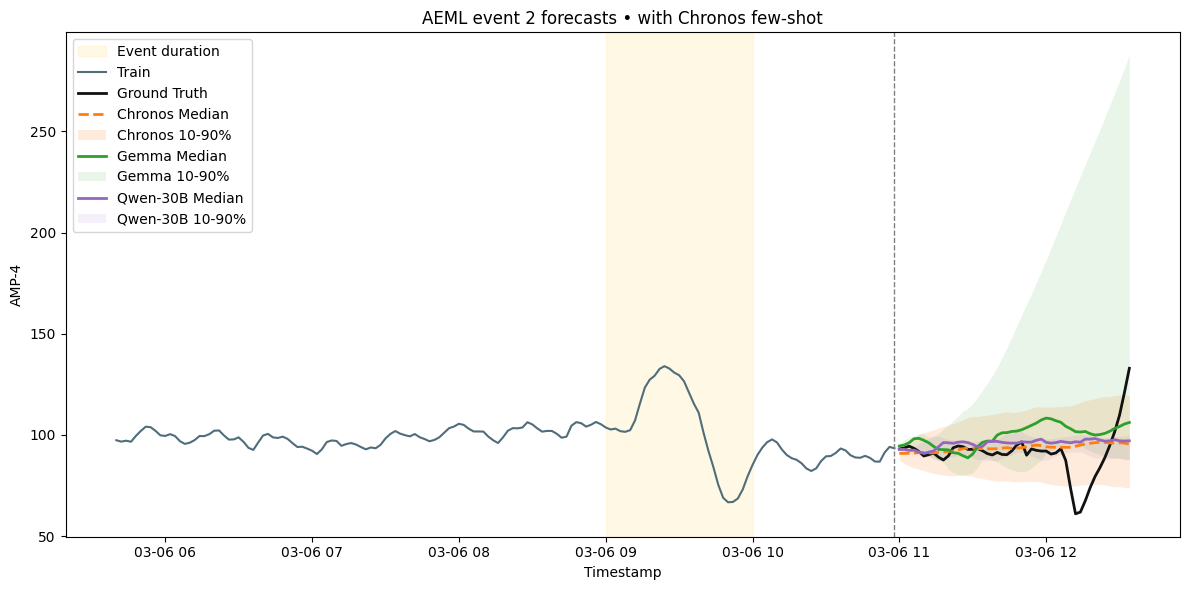

In [10]:
plot_title_with_few = f"AEML event {EVENT_NUMBER} forecasts • with Chronos few-shot"
plot_forecasts(
    train_series,
    test_series,
    chronos_series,
    few_shot_predictions,
    plot_title_with_few,
    chronos_interval=chronos_interval,
    event_range=(EVENT_WINDOWS[EVENT_NUMBER][0], EVENT_WINDOWS[EVENT_NUMBER][1]),
 )

In [11]:
no_few_shot_predictions = run_models(include_few_shot=False)
no_few_shot_mae = collect_mae(test_series, chronos_series, no_few_shot_predictions)
no_few_shot_mae

Sampling with best hyper... defaultdict(<class 'dict'>, {'model': 'gemma-12b', 'alpha': 0.3, 'basic': True, 'temp': 1.0, 'top_p': 0.8, 'settings': SerializerSettings(base=10, prec=3, signed=True, fixed_length=False, max_val=10000000.0, time_sep=',', bit_sep='', plus_sign='', minus_sign='-', half_bin_correction=True, decimal_point='', missing_str=' Nan'), 'dataset_name': 'AEML_event_forecast'}) 
 with NLL inf


  0%|          | 0/1 [00:00<?, ?it/s]2025-10-02 13:45:10.690 | DEBUG    | models.gemma:gemma_completion_fn:164 - Batch size: 5
2025-10-02 13:45:10.691 | DEBUG    | models.gemma:gemma_completion_fn:165 - Num samples: 5
2025-10-02 13:45:10.692 | DEBUG    | models.gemma:gemma_completion_fn:166 - num_samples // batchsize: 1
2025-10-02 13:45:10.698 | DEBUG    | models.gemma:gemma_completion_fn:169 - input_str: You are a time-series forecasting specialist. Return the future values as comma-separated decimals with no extra words.Predict the next values continuing the series. Output only comma-separated numbers and nothing else.1030,1023,1028,1022,1053,1079,1101,1098,1080,1056,1053,1062,1052,1025,1011,1017,1031,1052,1052,1062,1080,1081,1055,1033,1034,1045,1022,990,980,1019,1055,1063,1045,1042,1049,1037,1015,995,996,986,975,958,982,1021,1029,1026,1001,1010,1015,1008,994,983,992,988,1006,1039,1063,1078,1065,1056,1050,1062,1046,1036,1025,1032,1046,1070,1093,1102,1116,1110,1091,1076,1076,1076,1050

Sampling with best hyper... defaultdict(<class 'dict'>, {'model': 'qwen-30b', 'alpha': 0.3, 'basic': True, 'temp': 1.0, 'top_p': 0.8, 'settings': SerializerSettings(base=10, prec=3, signed=True, fixed_length=False, max_val=10000000.0, time_sep=',', bit_sep='', plus_sign='', minus_sign='-', half_bin_correction=True, decimal_point='', missing_str=' Nan'), 'dataset_name': 'AEML_event_forecast'}) 
 with NLL inf


  0%|          | 0/1 [00:00<?, ?it/s]2025-10-02 13:45:40.131 | DEBUG    | models.qwen:qwen_completion_fn:162 - Batch size: 5
2025-10-02 13:45:40.132 | DEBUG    | models.qwen:qwen_completion_fn:163 - Num samples: 5
2025-10-02 13:45:40.133 | DEBUG    | models.qwen:qwen_completion_fn:164 - num_samples // batchsize: 1
2025-10-02 13:45:40.139 | DEBUG    | models.qwen:qwen_completion_fn:167 - input_str: You are a time-series forecasting specialist. Return the future values as comma-separated decimals with no extra words.Predict the next values continuing the series. Output only comma-separated numbers and nothing else.1030,1023,1028,1022,1053,1079,1101,1098,1080,1056,1053,1062,1052,1025,1011,1017,1031,1052,1052,1062,1080,1081,1055,1033,1034,1045,1022,990,980,1019,1055,1063,1045,1042,1049,1037,1015,995,996,986,975,958,982,1021,1029,1026,1001,1010,1015,1008,994,983,992,988,1006,1039,1063,1078,1065,1056,1050,1062,1046,1036,1025,1032,1046,1070,1093,1102,1116,1110,1091,1076,1076,1076,1050,1030,10

,MAE
Model,
Chronos-Bolt (median),6.907380
Qwen-30B,9.195351
Gemma,13.781441


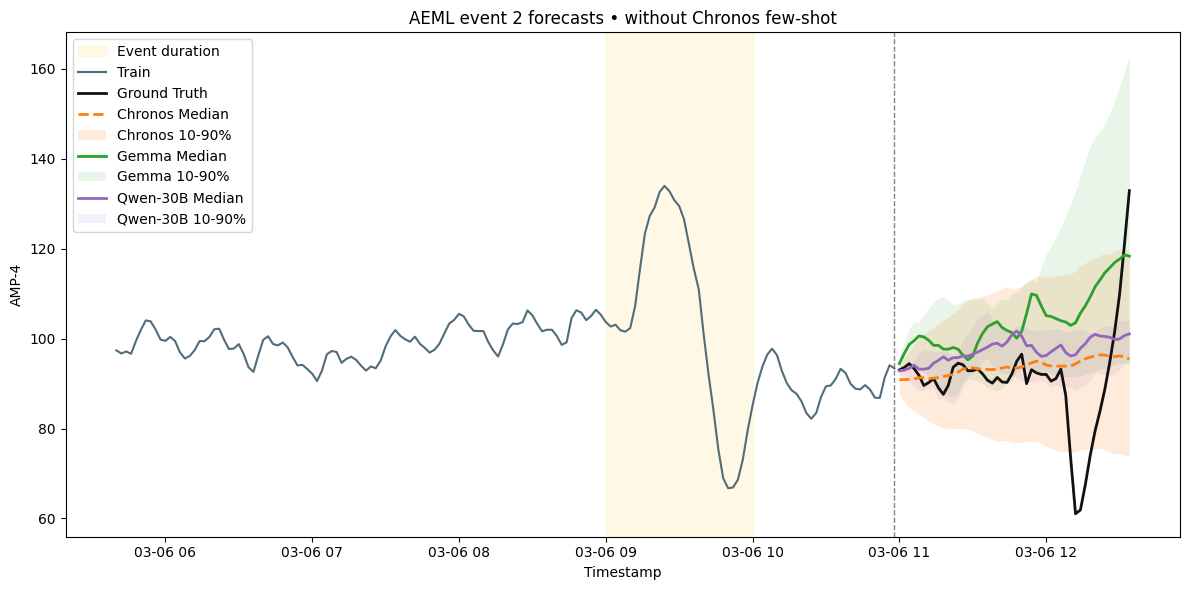

In [14]:
plot_title_without_few = f"AEML event {EVENT_NUMBER} forecasts • without Chronos few-shot"
plot_forecasts(
    train_series,
    test_series,
    chronos_series,
    no_few_shot_predictions,
    plot_title_without_few,
    chronos_interval=chronos_interval,
    event_range=(EVENT_WINDOWS[EVENT_NUMBER][0], EVENT_WINDOWS[EVENT_NUMBER][1]),
 )

In [13]:
comparison_mae = pd.concat(
    {
        "With Chronos few-shot": few_shot_mae,
        "Without Chronos few-shot": no_few_shot_mae,
    },
    axis=1,
 )
comparison_mae

,With Chronos few-shot,Without Chronos few-shot
,MAE,MAE
Model,,
Chronos-Bolt (median),6.907380,6.907380
Qwen-30B,8.173633,9.195351
Gemma,11.293938,13.781441
